In [1]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk




/home/paola/anaconda3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/paola/.lightkurve/cache. Please move all the files in the legacy directory /home/paola/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [2]:
#### Parametros do setor 1 ######
data=np.loadtxt('par_setor27_2Min.txt')
data5=np.loadtxt('par_s27_2min.txt')

dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener0 = data[:,4]
ener = data5
print(np.mean(ampl))


0.008582217567567569


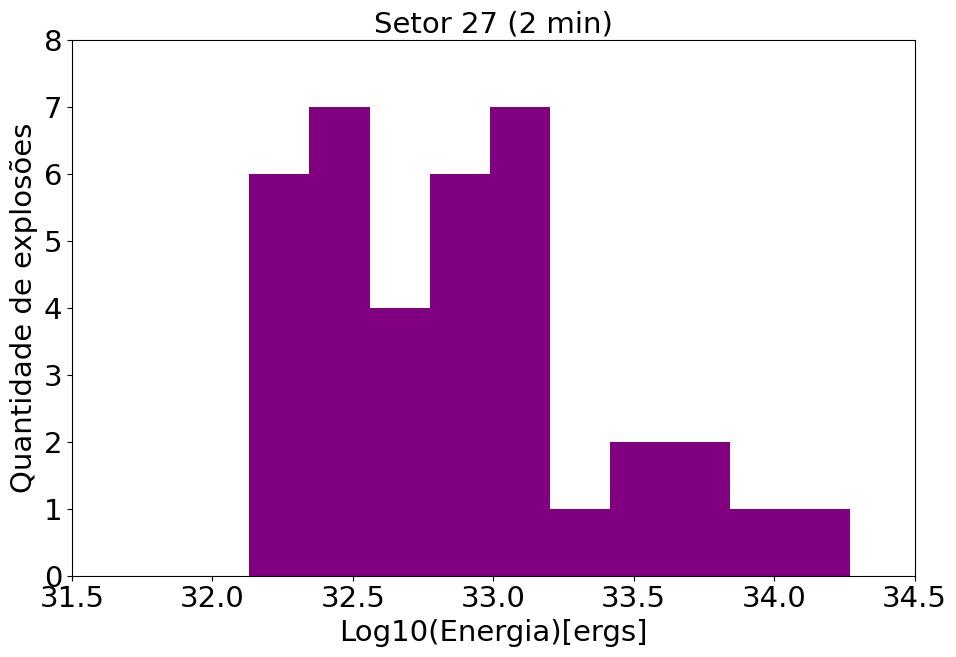

<Figure size 640x480 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

n_bins = 10

# Creating distribution
x = np.log10(ener)
y = len(ener)
plt.rcParams['font.size'] = '21'
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='purple', label = "d")
#labels= ["Energia"]
plt.ylabel("Quantidade de explosões").set_fontsize(21)
plt.xlabel("Log10(Energia)[ergs]").set_fontsize(21)
plt.title('Setor 27 (2 min)').set_fontsize(21)
plt.ylim(0,8)
plt.xlim(31.5,34.5)
#plt.legend(labels)
plt.xticks(fontsize = 21)
plt.yticks(fontsize = 21)
# Show plot
plt.show()
plt.savefig('nome_do_arquivo.png')

395.712


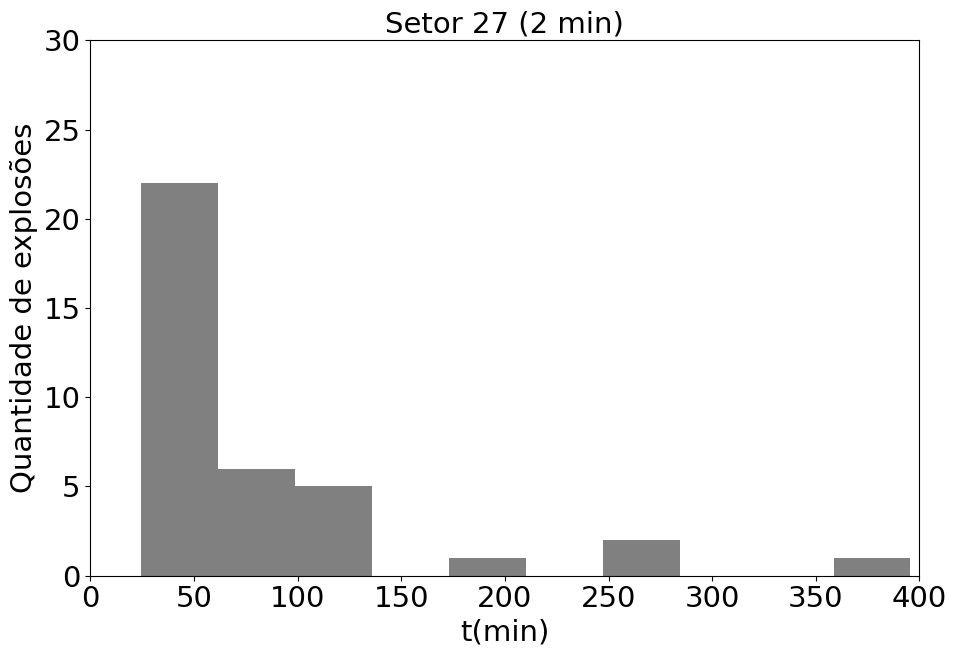

In [5]:
n_bins = 10

# Creating distribution
x = dur
y = len(dur)
print(np.max(dur))
plt.rcParams['font.size'] = '21' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 

axs.hist(x, bins = n_bins, color='gray', label = "d")
#labels= ["Duração"]
plt.ylabel("Quantidade de explosões").set_fontsize(21)
plt.xlabel("t(min)").set_fontsize(21)
plt.ylim(0,30)
plt.xlim(0,400)
plt.title('Setor 27 (2 min)').set_fontsize(21)
#plt.legend(labels)
plt.xticks(fontsize = 21)
plt.yticks(fontsize = 21)
# Save the plot before showing
plt.savefig('his_dur_1.png')

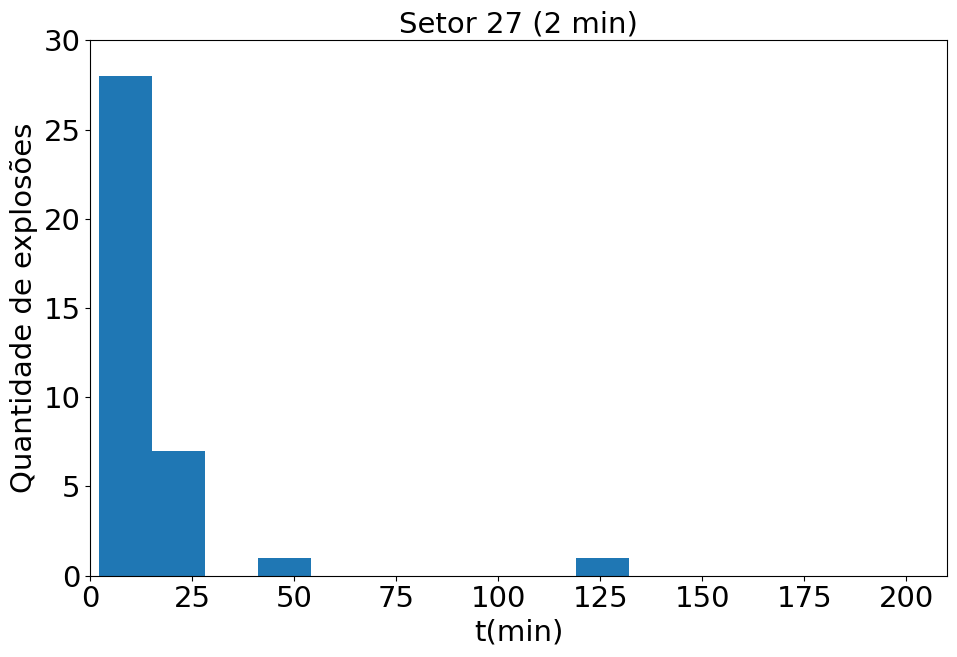

In [6]:
n_bins = 10

# Creating distribution
x = sub
y = len(sub)
plt.rcParams['font.size'] = '21' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins)
#labels= ["Tempo de subida"]
plt.ylabel("Quantidade de explosões").set_fontsize(21)
plt.xlabel("t(min)").set_fontsize(21)
plt.title('Setor 27 (2 min)').set_fontsize(21)
plt.ylim(0,30)
plt.xlim(0,210)
#plt.legend(labels)
plt.xticks(fontsize = 21)
plt.yticks(fontsize = 21)
plt.savefig('his_sub_1.png')

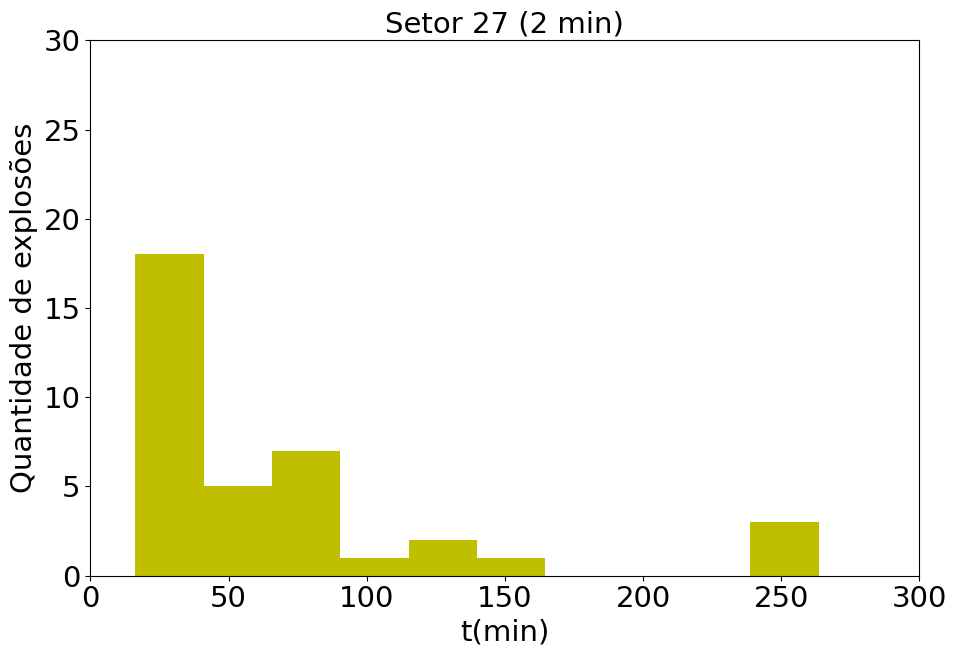

In [7]:

n_bins = 10

# Creating distribution
x = des
y = len(des)
plt.rcParams['font.size'] = '21'  
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='y')
#labels= ["Tempo de descida"]
plt.ylabel("Quantidade de explosões").set_fontsize(21)
plt.xlabel("t(min)").set_fontsize(21)
plt.title('Setor 27 (2 min)').set_fontsize(21)
#plt.legend(labels)
plt.ylim(0,30)
plt.xlim(0,300)

plt.xticks(fontsize = 21)
plt.yticks(fontsize = 21) 
plt.savefig('his_des_1.png')

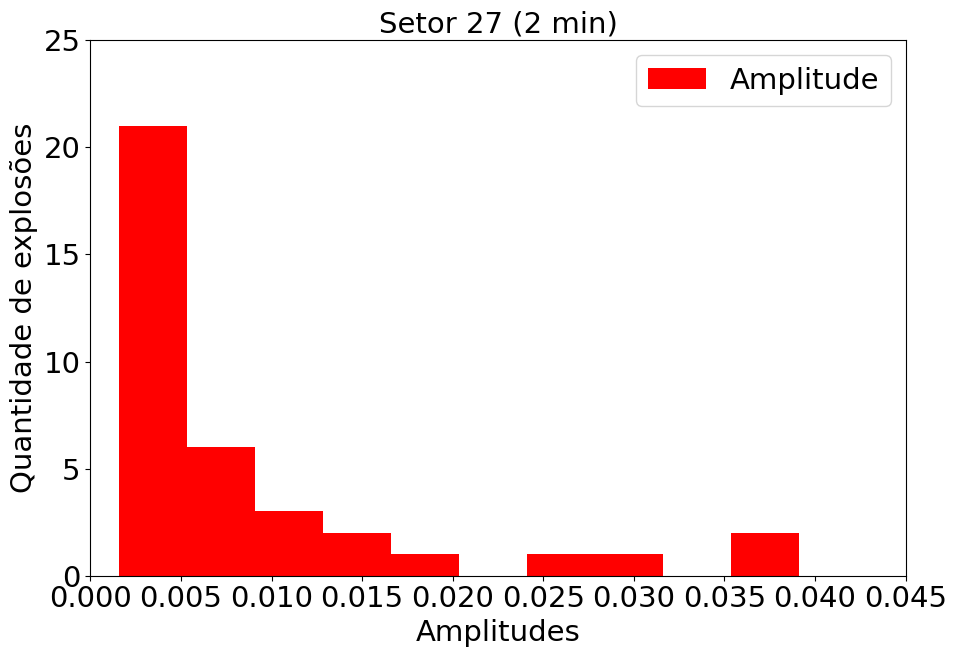

In [13]:
n_bins = 10

# Creating distribution
x = ampl
y = len(ampl)
plt.rcParams['font.size'] = '21' 
# Creating histogram
fig, axs = plt.subplots(1, 1,
                        figsize =(10, 7),
                        tight_layout = True)
 
axs.hist(x, bins = n_bins, color='red', label = "d")
labels= ["Amplitude"]
plt.ylabel("Quantidade de explosões").set_fontsize(21)
plt.xlabel("Amplitudes").set_fontsize(21)
plt.title('Setor 27 (2 min)').set_fontsize(21)
plt.ylim(0,25)
plt.xlim(0,0.045)

plt.legend(labels)
plt.xticks(fontsize = 21)
plt.yticks(fontsize = 21)  
plt.savefig('his_ampl_1')

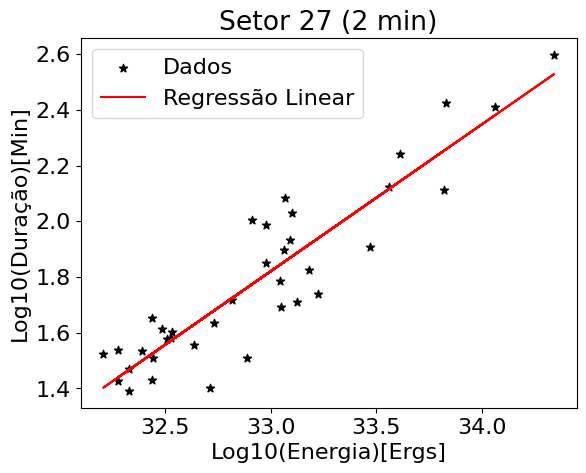

Coeficiente Angular (Slope): 0.526698287082071
Coeficiente Linear (Intercept): -15.560444775206772
Coeficiente de Correlação (r): 0.9134952330998535
Valor-p (p-value): 3.1187339685767594e-15
Erro Padrão (Standard Error): 0.03965110646239051


In [29]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Exemplo de dados de entrada e saída
X = np.log10(ener)
y = np.log10(dur)
# Use linregress para ajustar o modelo linear
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# Faça previsões para os valores existentes de X
predictions = slope *X + intercept

# Plote os dados originais e a linha de regressão
plt.scatter(X, y, label='Dados', color='black', marker="*")
plt.plot(X, predictions, label='Regressão Linear', color='red')
plt.ylabel('Log10(Duração)[Min]')
plt.xlabel('Log10(Energia)[Ergs]')
plt.legend()
plt.title('Setor 27 (2 min)')
plt.show()

# Imprima os coeficientes e outras estatísticas
print(f"Coeficiente Angular (Slope): {slope}")
print(f"Coeficiente Linear (Intercept): {intercept}")
print(f"Coeficiente de Correlação (r): {r_value}")
print(f"Valor-p (p-value): {p_value}")
print(f"Erro Padrão (Standard Error): {std_err}")
